## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

## Model Selection

- Support Vector Regression is chosen because its epsilon insensitive tube ignores small errors, this helps buffer out noise due to market volatility
- Linear kernel was chosen as it performed better over the other variants

In [ ]:
# Load the data into X and Y
df = pd.read_csv('../data/combined_monthly_running_avg_20.csv')
y = df['SP500']
X = df.drop(columns=['SP500'])

# Split date data
X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X = X.drop(columns=['Date'])

feature_names = X.columns.tolist()

# Print out X & y
display(X.head())
y

,Crude_Oil,US_10Y_Yield,Copper,Steel_PPI,CPI,Unemployment_Rate,Year,Month
0,92.190002,3.378,4.4510,220.4,221.187,9.1,2011,1
1,96.970001,3.414,4.4780,239.8,221.898,9.0,2011,2
2,106.720001,3.454,4.3000,248.1,223.046,9.0,2011,3
3,113.930000,3.296,4.1655,257.3,224.093,9.1,2011,4
4,95.419998,3.158,4.2720,250.3,224.806,9.1,2011,6


0      1286.119995
1      1327.219971
2      1325.829956
3      1363.609985
4      1320.640015
          ...     
133    4845.649902
134    5096.270020
135    5254.350098
136    5035.689941
137    5277.509766
Name: SP500, Length: 138, dtype: float64

In [3]:
# Split data into training set and testing set (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale features to have 0 mean and 1 std
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Hyperparameter grid
    # C is a regularisation parameter
    # epsilon margin
    # gamma is not applicable since using  linear kernel
param_grid = {
    'C':       [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    SVR(kernel='linear'),
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

# Find best hyperparameters
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV MSE     : {-grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters : {'C': 100, 'epsilon': 1.0}
Best CV MSE     : 290875.3953


In [4]:
# Retrieve the estimator found using grid search
svr = grid_search.best_estimator_

y_pred_svr = svr.predict(X_test_scaled)

mse  = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_svr)
r2   = r2_score(y_test, y_pred_svr)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 435693.9912
RMSE : 660.0712
MAE  : 586.8600
R²   : -1.2354


Permutation importances (mean increase in MSE when feature is shuffled):
CPI                  91054.710745
Steel_PPI            87467.180504
Year                 32620.599313
Copper               22141.665623
US_10Y_Yield          1517.987890
Crude_Oil              150.326227
Month                 -303.040709
Unemployment_Rate     -422.040891
dtype: float64


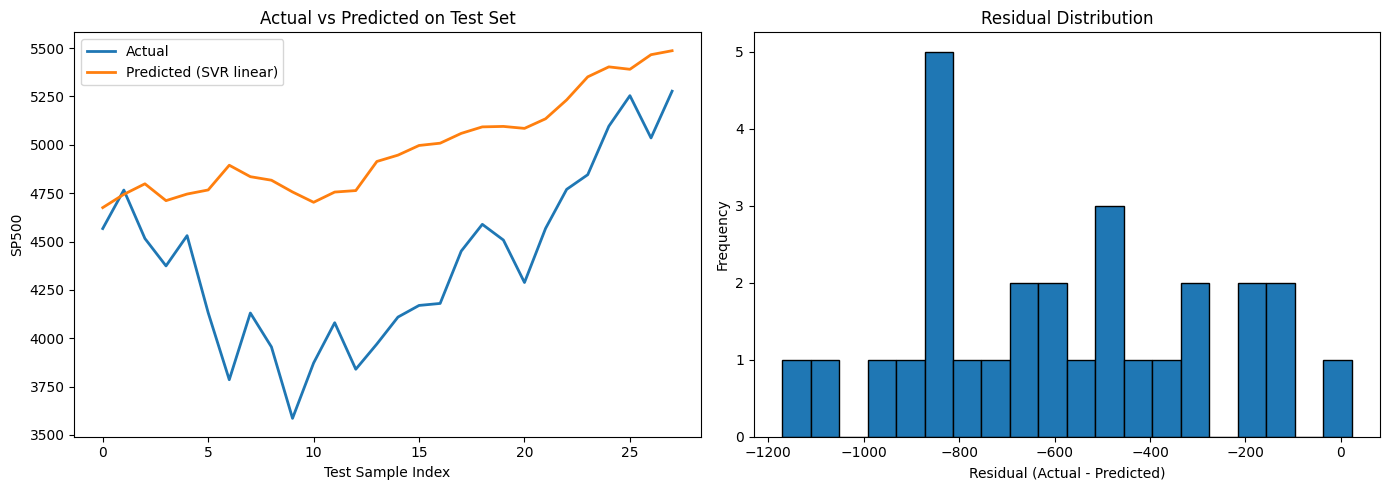

In [5]:
# Permutation importance, since SVR has no built in feature importance we will use permutation importance instead
perm = permutation_importance(
    svr, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error',
)

importances = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
print('Permutation importances (mean increase in MSE when feature is shuffled):')
print(importances)

# Calculate residuals
residuals = y_test.values - y_pred_svr

# Plot everything:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_test.values, label='Actual', linewidth=2)
axes[0].plot(y_pred_svr, label='Predicted (SVR linear)', linewidth=2)
axes[0].set_title('Actual vs Predicted on Test Set')
axes[0].set_xlabel('Test Sample Index')
axes[0].set_ylabel('SP500')
axes[0].legend()

axes[1].hist(residuals, bins=20, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()